# 06 — Baseline survival: demonstracja analizy przeżywalności

Notebook **demonstracyjny** pokazujący, że survival dataset wyprodukowany przez pipeline LUAD-HUBA jest gotowy do analizy przeżywalności. To nie jest pełna analiza naukowa (brak feature selection, cross-validation, optymalizacji modeli) — to dowód użyteczności: na danych z pipeline'u standardowe metody survival (Kaplan-Meier, Cox) po prostu działają.

**Cel pipeline'u był:** przygotować dane TCGA-LUAD do analizy przeżywalności. Ten notebook zamyka tę historię, pokazując że cel został osiągnięty.

**Zakres:**

1. Wczytanie survival_dataset z pipeline'u
2. Przygotowanie (collapse stage, encoding kowariantów)
3. Kaplan-Meier overall (mediana OS, przeżycie 1/3/5 lat)
4. Kaplan-Meier per stage + log-rank
5. Kaplan-Meier dla markera ekspresyjnego (NKX2-1 high vs low)
6. Cox proportional hazards (baseline kliniczny: age + gender + stage)
7. Wnioski

**Decyzje metodologiczne (z EDA + ustalenia projektowe):**
- Endpoint: OS (overall survival), TSS pominięty jako kowariant (EDA: brak batch effectu)
- Próg high/low ekspresji: mediana (najprostszy, brak data-snooping)
- Stage collapse: I/II/III/IV (4 grupy) - Stage IV n=25 za mało na 7-poziomowy podział
- Próbki: tumor_only (już w pipeline), 523 próbki

**Pakiety:** lifelines (już w deps). Jeśli brak: `uv add lifelines`.


## 1. Wczytanie survival dataset

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Paleta projektu - beże, brązy, zielenie (klimat lab/medical)
PALETTE = {
    "primary": "#5a8b3c",    # zieleń
    "secondary": "#8b5a3c",  # brąz
    "accent": "#c4a484",     # beż
    "dark": "#2a4a1c",       # ciemna zieleń
}

print(f"Projekt: {PROJECT_ROOT}")
print(f"lifelines załadowany | Polars: {pl.__version__}")
print(f"Czas: {datetime.now(timezone.utc).isoformat()}")


Projekt: /Users/luka/luad-huba-clean
lifelines załadowany | Polars: 1.40.1
Czas: 2026-06-12T11:14:05.444251+00:00


In [2]:
print("=== Wczytuję survival_dataset.parquet ===")
dataset_path = PROCESSED_DIR / "survival_dataset.parquet"
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Brak {dataset_path}\n"
        f"Uruchom najpierw pipeline: luad-huba build-survival --config configs/default.yaml"
    )

ds = pl.read_parquet(dataset_path)
meta_cols = ["sample_id", "case_id", "time", "event", "age_at_index",
             "gender", "ajcc_pathologic_stage", "tissue_type"]
gene_cols = [c for c in ds.columns if c.startswith("ENSG")]

print(f"Dataset: {ds.height} próbek × {ds.width} kolumn")
print(f"  Metadane: {len([c for c in meta_cols if c in ds.columns])} kolumn")
print(f"  Geny: {len(gene_cols)} kolumn")
print()
print("Podstawowe staty przeżycia:")
n_events = ds.filter(pl.col("event")).height
n_censored = ds.filter(~pl.col("event")).height
print(f"  Zdarzenia (zgony): {n_events} ({n_events/ds.height*100:.1f}%)")
print(f"  Cenzurowane:       {n_censored} ({n_censored/ds.height*100:.1f}%)")
print(f"  Czas obserwacji:   {ds['time'].min()}-{ds['time'].max()} dni "
      f"(mediana {ds['time'].median():.0f})")


=== Wczytuję survival_dataset.parquet ===
Dataset: 523 próbek × 19970 kolumn
  Metadane: 8 kolumn
  Geny: 19962 kolumn

Podstawowe staty przeżycia:
  Zdarzenia (zgony): 188 (35.9%)
  Cenzurowane:       335 (64.1%)
  Czas obserwacji:   4-7248 dni (mediana 691)


## 2. Przygotowanie danych

Trzy operacje:
- **Collapse stage** do 4 grup (I/II/III/IV) z podtypów (IA, IB → I itd.). Stage NOS i Unknown jako osobne kategorie (zgodnie z wcześniejszą decyzją - nie wycinamy, oznaczamy).
- **Konwersja do pandas** (lifelines pracuje na pandas, nie polars).
- **Encoding** gender i stage dla Cox.


In [3]:
def collapse_stage(stage: str) -> str:
    """Collapse szczegółowych stadiów do 4 głównych grup + NOS/Unknown."""
    if stage is None:
        return "Unknown"
    s = stage.replace("Stage ", "")
    if s in ("IV", "IVA", "IVB"):
        return "IV"
    if s.startswith("III"):
        return "III"
    if s.startswith("II"):
        return "II"
    if s.startswith("I"):
        return "I"
    return "Unknown"


# Surowy stage przed collapse - sprawdzenie
print("=== Stage przed collapse ===")
print(ds.group_by("ajcc_pathologic_stage").len().sort("ajcc_pathologic_stage"))

ds = ds.with_columns(
    pl.col("ajcc_pathologic_stage")
    .map_elements(collapse_stage, return_dtype=pl.Utf8)
    .alias("stage_group")
)

print()
print("=== Stage po collapse (4 grupy + NOS/Unknown) ===")
print(ds.group_by("stage_group").len().sort("stage_group"))


=== Stage przed collapse ===
shape: (10, 2)
┌───────────────────────┬─────┐
│ ajcc_pathologic_stage ┆ len │
│ ---                   ┆ --- │
│ str                   ┆ u32 │
╞═══════════════════════╪═════╡
│ null                  ┆ 8   │
│ Stage I               ┆ 5   │
│ Stage IA              ┆ 137 │
│ Stage IB              ┆ 146 │
│ Stage II              ┆ 1   │
│ Stage IIA             ┆ 48  │
│ Stage IIB             ┆ 72  │
│ Stage IIIA            ┆ 71  │
│ Stage IIIB            ┆ 10  │
│ Stage IV              ┆ 25  │
└───────────────────────┴─────┘

=== Stage po collapse (4 grupy + NOS/Unknown) ===
shape: (5, 2)
┌─────────────┬─────┐
│ stage_group ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ null        ┆ 8   │
│ I           ┆ 288 │
│ II          ┆ 121 │
│ III         ┆ 81  │
│ IV          ┆ 25  │
└─────────────┴─────┘


In [4]:
# Konwersja do pandas dla lifelines
# Bierzemy tylko kolumny potrzebne do analizy (metadane + wybrane geny później)
pdf = ds.select(meta_cols + ["stage_group"]).to_pandas()

# time w latach (z dni) dla czytelności wykresów
pdf["time_years"] = pdf["time"] / 365.25

print(f"Pandas DataFrame: {pdf.shape}")
print()
print("Typy danych:")
print(pdf[["time", "time_years", "event", "age_at_index", "gender", "stage_group"]].dtypes)
print()
print("Podgląd:")
print(pdf[["case_id", "time_years", "event", "age_at_index", "gender", "stage_group"]].head())


Pandas DataFrame: (523, 10)

Typy danych:
time              int64
time_years      float64
event              bool
age_at_index    float64
gender           object
stage_group      object
dtype: object

Podgląd:
        case_id  time_years  event  age_at_index  gender stage_group
0  TCGA-05-4245    1.998631  False          81.0    male         III
1  TCGA-05-4249    4.169747  False          67.0    male           I
2  TCGA-05-4250    0.331280   True          79.0  female         III
3  TCGA-05-4382    1.661875  False          68.0    male           I
4  TCGA-05-4384    1.166324  False          66.0    male         III


## 3. Kaplan-Meier — cała kohorta

Podstawowa krzywa przeżycia dla wszystkich pacjentów. Mediana OS i przeżycie w punktach 1, 3, 5 lat.


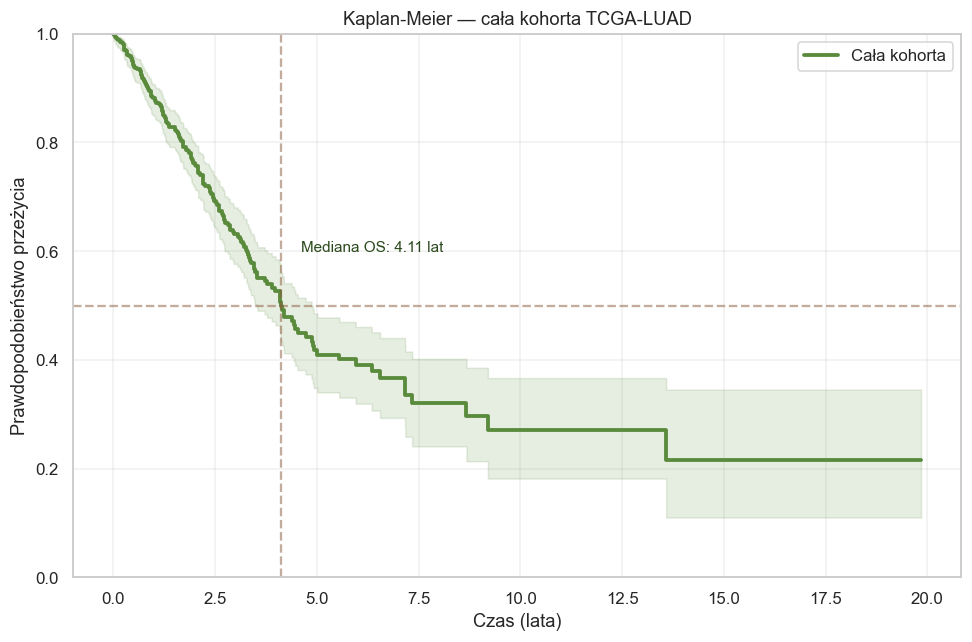

=== Statystyki przeżycia ===
Mediana OS: 4.11 lat

  Przeżycie 1-letnie: 88.2%
  Przeżycie 3-letnie: 63.1%
  Przeżycie 5-letnie: 41.8%


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(pdf["time_years"], pdf["event"], label="Cała kohorta")

fig, ax = plt.subplots(figsize=(9, 6))
kmf.plot_survival_function(ax=ax, color=PALETTE["primary"], linewidth=2.5, ci_alpha=0.15)
ax.set_xlabel("Czas (lata)")
ax.set_ylabel("Prawdopodobieństwo przeżycia")
ax.set_title("Kaplan-Meier — cała kohorta TCGA-LUAD")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

# Mediana OS
median_os = kmf.median_survival_time_
ax.axhline(0.5, color=PALETTE["secondary"], linestyle="--", alpha=0.5)
if not np.isnan(median_os):
    ax.axvline(median_os, color=PALETTE["secondary"], linestyle="--", alpha=0.5)
    ax.annotate(f"Mediana OS: {median_os:.2f} lat",
                xy=(median_os, 0.5), xytext=(median_os + 0.5, 0.6),
                fontsize=10, color=PALETTE["dark"])

plt.tight_layout()
plt.show()

print(f"=== Statystyki przeżycia ===")
print(f"Mediana OS: {median_os:.2f} lat" if not np.isnan(median_os) else "Mediana OS: nieosiągnięta")
print()
for years in [1, 3, 5]:
    surv = kmf.survival_function_at_times(years).iloc[0]
    print(f"  Przeżycie {years}-letnie: {surv*100:.1f}%")


## 4. Kaplan-Meier per stage

Czy stadium różnicuje przeżycie? Powinno — to podstawowy sanity check kliniczny (zaawansowane stadia = gorsze rokowanie). Log-rank test sprawdza istotność różnic między grupami.


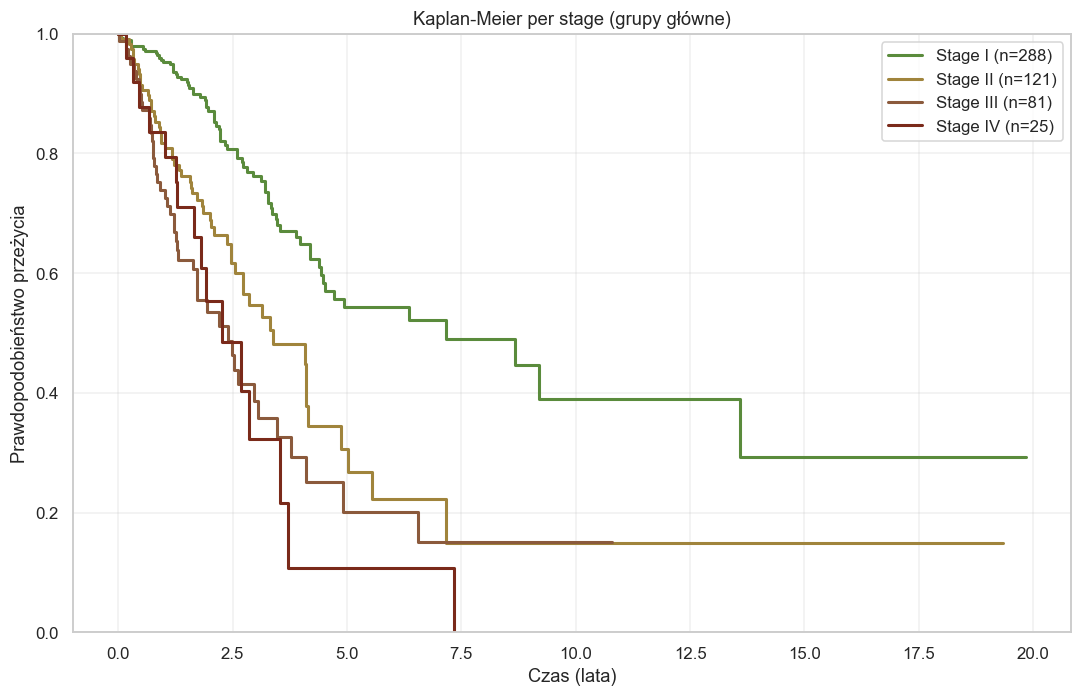

In [6]:
fig, ax = plt.subplots(figsize=(10, 6.5))

stage_order = ["I", "II", "III", "IV"]
stage_colors = ["#5a8b3c", "#a0843c", "#8b5a3c", "#7a2a1a"]  # zieleń -> brąz -> czerwień

for stage, color in zip(stage_order, stage_colors):
    mask = pdf["stage_group"] == stage
    n = mask.sum()
    if n < 5:
        continue
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(pdf.loc[mask, "time_years"], pdf.loc[mask, "event"],
              label=f"Stage {stage} (n={n})")
    kmf_s.plot_survival_function(ax=ax, color=color, linewidth=2, ci_show=False)

ax.set_xlabel("Czas (lata)")
ax.set_ylabel("Prawdopodobieństwo przeżycia")
ax.set_title("Kaplan-Meier per stage (grupy główne)")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Log-rank test - czy różnice między stage są istotne
main_stages = pdf[pdf["stage_group"].isin(stage_order)].copy()
results = multivariate_logrank_test(
    main_stages["time_years"],
    main_stages["stage_group"],
    main_stages["event"],
)
print("=== Log-rank test (różnice między stage I/II/III/IV) ===")
print(f"  Test statistic: {results.test_statistic:.2f}")
print(f"  p-value: {results.p_value:.2e}")
print()
if results.p_value < 0.05:
    print("  Stadium istotnie różnicuje przeżycie (p < 0.05) - zgodne z oczekiwaniem klinicznym.")
else:
    print("  Brak istotnej różnicy (p >= 0.05) - nietypowe, wymaga sprawdzenia.")


=== Log-rank test (różnice między stage I/II/III/IV) ===
  Test statistic: 58.73
  p-value: 1.10e-12

  Stadium istotnie różnicuje przeżycie (p < 0.05) - zgodne z oczekiwaniem klinicznym.


## 5. Kaplan-Meier dla markera ekspresyjnego — NKX2-1

**Najważniejsza sekcja z perspektywy celu pipeline'u** — pokazuje, że pipeline łączy ekspresję genów z danymi przeżycia, i że standardowa analiza (stratyfikacja high/low + log-rank) działa.

NKX2-1 (TTF1) to marker różnicowania pęcherzykowego LUAD. Utrata jego ekspresji wiąże się klinicznie z gorszym rokowaniem. Sprawdzamy, czy widać to w danych z pipeline'u: pacjenci podzieleni na high/low względem **mediany** ekspresji NKX2-1.


In [8]:
# NKX2-1 ENSG00000136352 - znajdź kolumnę (z sufiksem wersji)
NKX2_1_BASE = "ENSG00000136352"
nkx_col = None
for c in gene_cols:
    if c.startswith(NKX2_1_BASE + ".") or c == NKX2_1_BASE:
        nkx_col = c
        break

if nkx_col is None:
    print(f"NKX2-1 ({NKX2_1_BASE}) nie znaleziony w genach datasetu!")
else:
    print(f"NKX2-1 znaleziony: {nkx_col}")
    # Dodaj ekspresję NKX2-1 do pandas (log2 TPM+1 dla czytelności, ale dataset
    # ma surowe wartości metryki - sprawdzamy jaka metryka)
    nkx_expr = ds[nkx_col].to_numpy()
    pdf["nkx2_1"] = nkx_expr
    pdf["nkx2_1_log"] = np.log2(nkx_expr + 1)

    median_nkx = np.median(nkx_expr)
    pdf["nkx2_1_group"] = np.where(pdf["nkx2_1"] >= median_nkx, "High", "Low")

    print(f"  Mediana ekspresji NKX2-1: {median_nkx:.2f}")
    print(f"  High (>= mediana): {(pdf['nkx2_1_group'] == 'High').sum()} pacjentów")
    print(f"  Low (< mediana):   {(pdf['nkx2_1_group'] == 'Low').sum()} pacjentów")


NKX2-1 znaleziony: ENSG00000136352.19
  Mediana ekspresji NKX2-1: 134.12
  High (>= mediana): 262 pacjentów
  Low (< mediana):   261 pacjentów


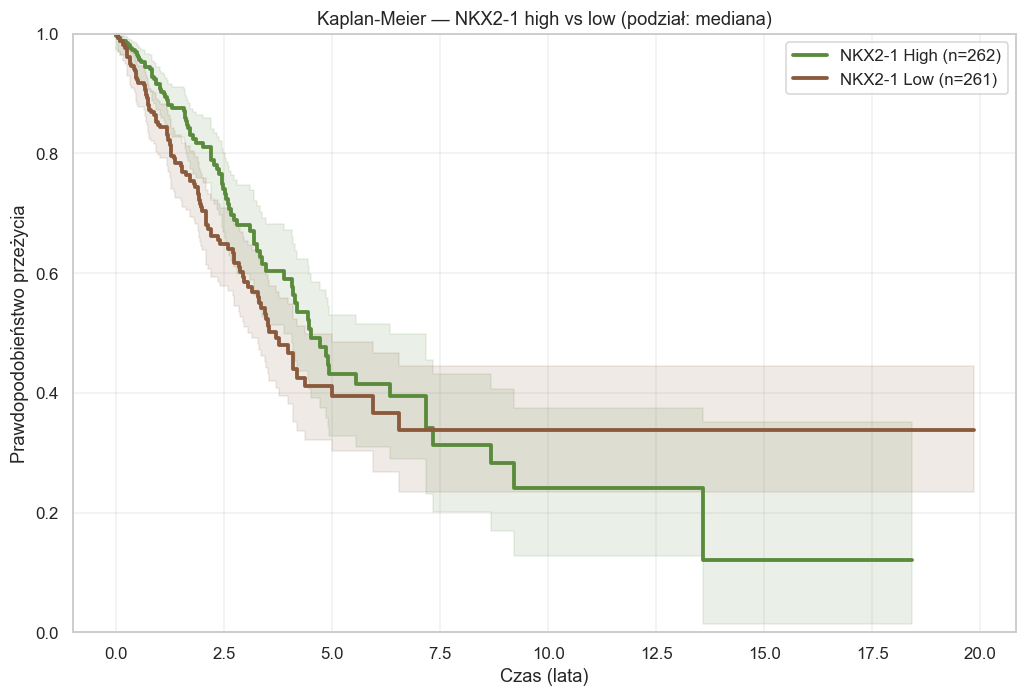

=== Log-rank test (NKX2-1 high vs low) ===
  Test statistic: 3.10
  p-value: 0.0784

  Brak istotnej różnicy (p=0.0784). To OK dla baseline -
  pojedynczy gen nie musi być prognostyczny. Ważne że mechanizm działa.


In [9]:
if nkx_col is not None:
    fig, ax = plt.subplots(figsize=(9.5, 6.5))

    for group, color in [("High", PALETTE["primary"]), ("Low", PALETTE["secondary"])]:
        mask = pdf["nkx2_1_group"] == group
        n = mask.sum()
        kmf_g = KaplanMeierFitter()
        kmf_g.fit(pdf.loc[mask, "time_years"], pdf.loc[mask, "event"],
                  label=f"NKX2-1 {group} (n={n})")
        kmf_g.plot_survival_function(ax=ax, color=color, linewidth=2.5, ci_alpha=0.12)

    ax.set_xlabel("Czas (lata)")
    ax.set_ylabel("Prawdopodobieństwo przeżycia")
    ax.set_title("Kaplan-Meier — NKX2-1 high vs low (podział: mediana)")
    ax.set_ylim(0, 1.0)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Log-rank high vs low
    high_mask = pdf["nkx2_1_group"] == "High"
    low_mask = pdf["nkx2_1_group"] == "Low"
    lr = logrank_test(
        pdf.loc[high_mask, "time_years"], pdf.loc[low_mask, "time_years"],
        pdf.loc[high_mask, "event"], pdf.loc[low_mask, "event"],
    )
    print(f"=== Log-rank test (NKX2-1 high vs low) ===")
    print(f"  Test statistic: {lr.test_statistic:.2f}")
    print(f"  p-value: {lr.p_value:.4f}")
    print()
    if lr.p_value < 0.05:
        print(f"  Ekspresja NKX2-1 istotnie różnicuje przeżycie (p={lr.p_value:.4f}).")
        print("  Pipeline poprawnie łączy ekspresję z danymi survival.")
    else:
        print(f"  Brak istotnej różnicy (p={lr.p_value:.4f}). To OK dla baseline -")
        print("  pojedynczy gen nie musi być prognostyczny. Ważne że mechanizm działa.")


## 6. Cox proportional hazards — baseline kliniczny

Model Coxa z kowariantami klinicznymi: wiek, płeć, stadium. **TSS pominięty** — EDA wykazała brak batch effectu, więc nie ma potrzeby kontrolować ośrodka. To dowód, że kowarianty z pipeline'u są poprawnie zakodowane i fitują standardowy model.


In [10]:
# Przygotowanie do Cox - encoding
cox_df = pdf[pdf["stage_group"].isin(stage_order)].copy()  # tylko główne stadia

# Encoding: gender binarnie, stage jako uporządkowane (I=1 ... IV=4)
cox_df["gender_male"] = (cox_df["gender"] == "male").astype(int)
stage_map = {"I": 1, "II": 2, "III": 3, "IV": 4}
cox_df["stage_numeric"] = cox_df["stage_group"].map(stage_map)

# Dataset do Cox: time, event + kowarianty
cox_input = cox_df[["time_years", "event", "age_at_index", "gender_male", "stage_numeric"]].copy()
cox_input = cox_input.dropna()

print(f"=== Cox input: {cox_input.shape[0]} pacjentów ===")
print(f"  (z {pdf.shape[0]} - odrzucono NOS/Unknown stage i braki)")
print()
print("Kowarianty:")
print(f"  age_at_index: {cox_input['age_at_index'].min():.0f}-{cox_input['age_at_index'].max():.0f} "
      f"(mean {cox_input['age_at_index'].mean():.1f})")
print(f"  gender_male: {cox_input['gender_male'].sum()} mężczyzn / "
      f"{(cox_input['gender_male']==0).sum()} kobiet")
print(f"  stage_numeric: rozkład {dict(cox_input['stage_numeric'].value_counts().sort_index())}")


=== Cox input: 505 pacjentów ===
  (z 523 - odrzucono NOS/Unknown stage i braki)

Kowarianty:
  age_at_index: 33-88 (mean 65.0)
  gender_male: 232 mężczyzn / 273 kobiet
  stage_numeric: rozkład {1: np.int64(281), 2: np.int64(119), 3: np.int64(80), 4: np.int64(25)}


In [11]:
cph = CoxPHFitter()
cph.fit(cox_input, duration_col="time_years", event_col="event")

print("=== Cox proportional hazards - podsumowanie ===")
cph.print_summary()


=== Cox proportional hazards - podsumowanie ===


<lifelines.CoxPHFitter: fitted with 505 total observations, 322 right-censored observations>
             duration col = 'time_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 505
number of events observed = 183
   partial log-likelihood = -959.90
         time fit was run = 2026-06-12 11:14:07 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
age_at_index   0.01      1.01      0.01           -0.01            0.02                0.99                1.02
gender_male   -0.01      0.99      0.15           -0.30            0.29                0.74                1.33
stage_numeric  0.49      1.64      0.07            0.35            0.63                1.42                1.88

               cmp to     z      p  -log2(p)
covariate                                   
age_at_index     0.00  0.92   0.36      1.49
gender_male      0.00 -0.06   0.95      0.07
stage_numeric    0.00  6.87 <0.005     37.13
---
Concordance = 0.66
Partial AIC = 1925.79
log-likelihood ratio test = 43.37 on 3 df
-log2(p) of ll-ratio test = 28.86

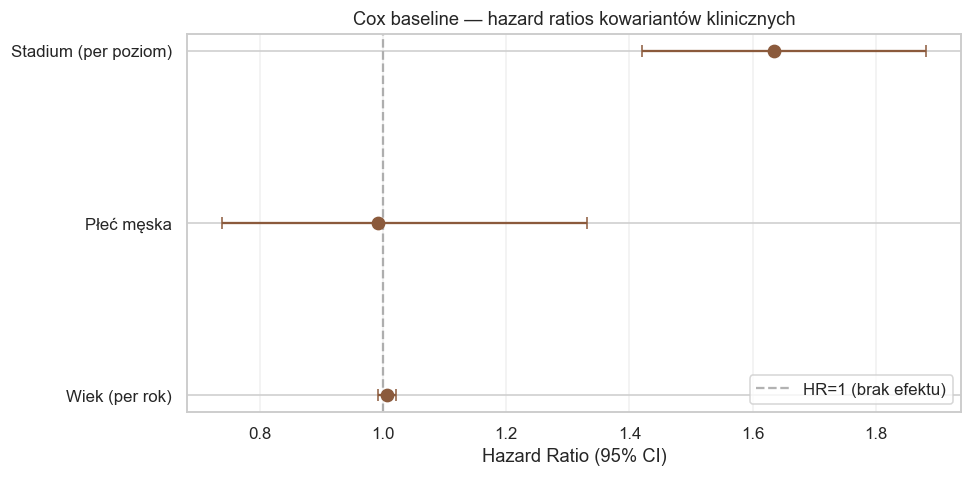

=== C-index modelu: 0.6610 ===
(0.5 = losowy, 1.0 = perfekcyjny; dla baseline klinicznego typowo 0.6-0.7)


In [12]:
# Forest plot hazard ratios
fig, ax = plt.subplots(figsize=(9, 4.5))

summary = cph.summary
hr = summary["exp(coef)"]
ci_lower = summary["exp(coef) lower 95%"]
ci_upper = summary["exp(coef) upper 95%"]
labels_map = {
    "age_at_index": "Wiek (per rok)",
    "gender_male": "Płeć męska",
    "stage_numeric": "Stadium (per poziom)",
}
y_pos = range(len(summary))

ax.errorbar(hr, y_pos, xerr=[hr - ci_lower, ci_upper - hr],
            fmt="o", color=PALETTE["secondary"], markersize=8, capsize=4, linewidth=1.5)
ax.axvline(1.0, color="grey", linestyle="--", alpha=0.6, label="HR=1 (brak efektu)")
ax.set_yticks(y_pos)
ax.set_yticklabels([labels_map.get(idx, idx) for idx in summary.index])
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Cox baseline — hazard ratios kowariantów klinicznych")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"=== C-index modelu: {cph.concordance_index_:.4f} ===")
print("(0.5 = losowy, 1.0 = perfekcyjny; dla baseline klinicznego typowo 0.6-0.7)")


## 7. Sygnatura wielogenowa — kombinacja genów (signature score)

Pojedynczy gen (NKX2-1, sekcja 5) dał p=0.078 — trend, ale poniżej progu istotności. To typowe: pojedynczy gen rzadko jest silnym niezależnym predyktorem. Sprawdzamy hipotezę, że **kombinacja genów** niesie więcej sygnału niż pojedynczy marker.

**Panel ekspresyjny (a priori, z literatury LUAD).** Kluczowe: panel wybrany jest **z góry na podstawie wiedzy biologicznej**, NIE przez przeglądanie p-value wszystkich genów (to byłby data snooping). Geny dobrano tak, by ich *poziom ekspresji* miał udokumentowaną wartość prognostyczną w LUAD (w przeciwieństwie do genów driverowych jak KRAS/EGFR/ALK, które działają przez mutacje/fuzje niewidoczne w ekspresji RNA).

Trzy osie biologiczne:

| Oś | Geny | Kierunek |
|---|---|---|
| Różnicowanie pęcherzykowe | NKX2-1, NAPSA, SFTPC | wysokie = lepsze rokowanie |
| Proliferacja | MKI67, TOP2A, BIRC5 | wysokie = gorsze rokowanie |
| Inwazja/przerzutowanie | SPP1 | wysokie = gorsze rokowanie |

**Signature score:** dla każdego pacjenta liczymy z-score ekspresji każdego genu (standaryzacja log2 TPM), odwracamy znak genów "dobrych" (różnicowanie), i sumujemy. Wysoki score = profil agresywny (niska różnicowanie + wysoka proliferacja/inwazja). Dzielimy pacjentów high/low względem mediany score i robimy KM + log-rank.


In [13]:
# Panel ekspresyjny a priori (geny których EKSPRESJA niesie sygnał prognostyczny)
SIGNATURE_PANEL = {
    # Różnicowanie pęcherzykowe (wysokie = lepiej) -> znak ujemny w score agresywności
    "NKX2-1": ("ENSG00000136352", -1),
    "NAPSA":  ("ENSG00000131400", -1),
    "SFTPC":  ("ENSG00000168484", -1),
    # Proliferacja (wysokie = gorzej) -> znak dodatni
    "MKI67":  ("ENSG00000148773", +1),
    "TOP2A":  ("ENSG00000131747", +1),
    "BIRC5":  ("ENSG00000089685", +1),
    # Inwazja (wysokie = gorzej) -> znak dodatni
    "SPP1":   ("ENSG00000118785", +1),
}

def find_gene_col(ensg_base, gene_cols):
    for c in gene_cols:
        if c.startswith(ensg_base + ".") or c == ensg_base:
            return c
    return None

# Mapowanie panel -> kolumny w macierzy
panel_cols = {}
print("=== Weryfikacja obecności genów panelu w macierzy ===")
for symbol, (ensg, sign) in SIGNATURE_PANEL.items():
    col = find_gene_col(ensg, gene_cols)
    if col is not None:
        panel_cols[symbol] = (col, sign)
        print(f"  {symbol:8} {ensg:20} znak={sign:+d}  -> {col}")
    else:
        print(f"  {symbol:8} {ensg:20} NIE ZNALEZIONO - pomijam")

print(f"\nGenów w panelu: {len(panel_cols)}/{len(SIGNATURE_PANEL)}")


=== Weryfikacja obecności genów panelu w macierzy ===
  NKX2-1   ENSG00000136352      znak=-1  -> ENSG00000136352.19
  NAPSA    ENSG00000131400      znak=-1  -> ENSG00000131400.8
  SFTPC    ENSG00000168484      znak=-1  -> ENSG00000168484.12
  MKI67    ENSG00000148773      znak=+1  -> ENSG00000148773.14
  TOP2A    ENSG00000131747      znak=+1  -> ENSG00000131747.15
  BIRC5    ENSG00000089685      znak=+1  -> ENSG00000089685.15
  SPP1     ENSG00000118785      znak=+1  -> ENSG00000118785.14

Genów w panelu: 7/7


In [14]:
# Signature score: suma znakowanych z-score ekspresji log2(TPM+1)
import numpy as np

score = np.zeros(ds.height)
for symbol, (col, sign) in panel_cols.items():
    expr = ds[col].to_numpy().astype(float)
    expr_log = np.log2(expr + 1)
    # z-score (standaryzacja)
    z = (expr_log - expr_log.mean()) / expr_log.std()
    score += sign * z

pdf["signature_score"] = score
median_score = np.median(score)
pdf["signature_group"] = np.where(pdf["signature_score"] >= median_score, "High (agresywny)", "Low (łagodny)")

print(f"=== Signature score (suma {len(panel_cols)} znakowanych z-score) ===")
print(f"  Zakres: {score.min():.2f} ... {score.max():.2f}")
print(f"  Mediana: {median_score:.3f}")
print(f"  High (>= mediana, profil agresywny): {(pdf['signature_group'] == 'High (agresywny)').sum()} pacjentów")
print(f"  Low  (< mediana, profil łagodny):    {(pdf['signature_group'] == 'Low (łagodny)').sum()} pacjentów")


=== Signature score (suma 7 znakowanych z-score) ===
  Zakres: -10.98 ... 13.68
  Mediana: 0.058
  High (>= mediana, profil agresywny): 262 pacjentów
  Low  (< mediana, profil łagodny):    261 pacjentów


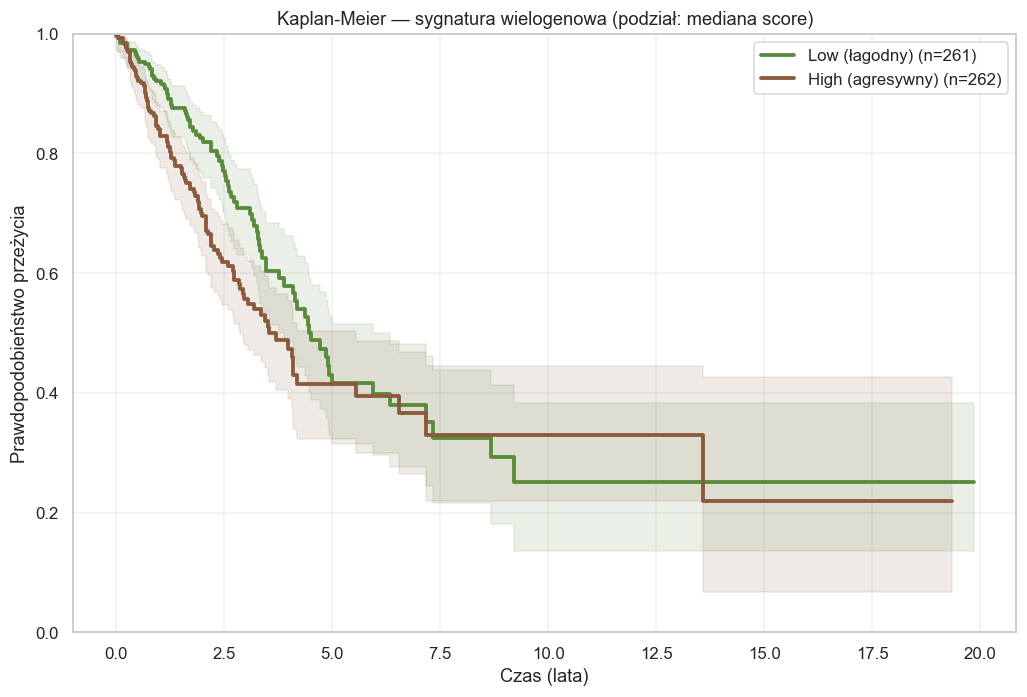

=== Log-rank test (sygnatura high vs low) ===
  Test statistic: 5.41
  p-value: 0.0200

Porównanie z pojedynczym NKX2-1 (sekcja 5): p=0.078
  Sygnatura wielogenowa ISTOTNA (p=0.0200) tam gdzie pojedynczy gen nie był.
  Kombinacja genów niesie więcej sygnału prognostycznego niż pojedynczy marker.


In [15]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

for group, color in [("Low (łagodny)", PALETTE["primary"]), ("High (agresywny)", PALETTE["secondary"])]:
    mask = pdf["signature_group"] == group
    n = mask.sum()
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(pdf.loc[mask, "time_years"], pdf.loc[mask, "event"], label=f"{group} (n={n})")
    kmf_g.plot_survival_function(ax=ax, color=color, linewidth=2.5, ci_alpha=0.12)

ax.set_xlabel("Czas (lata)")
ax.set_ylabel("Prawdopodobieństwo przeżycia")
ax.set_title("Kaplan-Meier — sygnatura wielogenowa (podział: mediana score)")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Log-rank high vs low
high_mask = pdf["signature_group"] == "High (agresywny)"
low_mask = pdf["signature_group"] == "Low (łagodny)"
lr_sig = logrank_test(
    pdf.loc[high_mask, "time_years"], pdf.loc[low_mask, "time_years"],
    pdf.loc[high_mask, "event"], pdf.loc[low_mask, "event"],
)
print(f"=== Log-rank test (sygnatura high vs low) ===")
print(f"  Test statistic: {lr_sig.test_statistic:.2f}")
print(f"  p-value: {lr_sig.p_value:.4f}")
print()
print(f"Porównanie z pojedynczym NKX2-1 (sekcja 5): p=0.078")
if lr_sig.p_value < 0.05:
    print(f"  Sygnatura wielogenowa ISTOTNA (p={lr_sig.p_value:.4f}) tam gdzie pojedynczy gen nie był.")
    print(f"  Kombinacja genów niesie więcej sygnału prognostycznego niż pojedynczy marker.")
else:
    print(f"  Sygnatura p={lr_sig.p_value:.4f} - {'silniejszy trend niż pojedynczy gen' if lr_sig.p_value < 0.078 else 'podobnie jak pojedynczy gen'}.")
    print(f"  W tej kohorcie OS sygnatura {'zbliża się do' if lr_sig.p_value < 0.1 else 'nie osiąga'} istotności.")


## 8. Multivariate Cox — panel genów + kowarianty kliniczne

Czy panel genów dodaje wartość prognostyczną **ponad** sam model kliniczny (wiek + płeć + stadium z sekcji 6)? Budujemy rozszerzony Cox: kowarianty kliniczne + ekspresja genów panelu (log2 TPM, z-score). Porównujemy C-index modelu klinicznego (sekcja 6) z modelem klinika+geny.

Każdy gen wchodzi jako osobny predyktor (nie zsumowany score) — to pokazuje **które konkretnie geny** są niezależnie istotne po korekcie o stadium. Kierunki HR powinny być zgodne z biologią: geny różnicowania HR<1 (ochronne), proliferacji/inwazji HR>1 (ryzyko).


In [16]:
# Rozszerzony Cox: kowarianty kliniczne + geny panelu (z-score log2 TPM)
cox_genes_df = pdf[pdf["stage_group"].isin(stage_order)].copy()
cox_genes_df["gender_male"] = (cox_genes_df["gender"] == "male").astype(int)
cox_genes_df["stage_numeric"] = cox_genes_df["stage_group"].map(stage_map)

# Dodaj z-score ekspresji każdego genu panelu
gene_feature_names = []
for symbol, (col, sign) in panel_cols.items():
    expr = ds[col].to_numpy().astype(float)
    expr_log = np.log2(expr + 1)
    z = (expr_log - expr_log.mean()) / expr_log.std()
    # dopasuj do wierszy cox_genes_df (po indeksie pdf)
    feat_name = f"g_{symbol.replace('-','_')}"
    pdf[feat_name] = z  # najpierw do pdf
    gene_feature_names.append(feat_name)

# Przebuduj cox_genes_df żeby zawierał kolumny genów
cox_genes_df = pdf[pdf["stage_group"].isin(stage_order)].copy()
cox_genes_df["gender_male"] = (cox_genes_df["gender"] == "male").astype(int)
cox_genes_df["stage_numeric"] = cox_genes_df["stage_group"].map(stage_map)

cox_cols = ["time_years", "event", "age_at_index", "gender_male", "stage_numeric"] + gene_feature_names
cox_genes_input = cox_genes_df[cox_cols].dropna()

print(f"=== Cox input (klinika + {len(gene_feature_names)} genów): {cox_genes_input.shape[0]} pacjentów ===")
print(f"Predyktory: age, gender, stage + {', '.join(s.replace('g_','') for s in gene_feature_names)}")


=== Cox input (klinika + 7 genów): 505 pacjentów ===
Predyktory: age, gender, stage + NKX2_1, NAPSA, SFTPC, MKI67, TOP2A, BIRC5, SPP1


In [17]:
cph_genes = CoxPHFitter()
cph_genes.fit(cox_genes_input, duration_col="time_years", event_col="event")

print("=== Multivariate Cox (klinika + panel genów) ===")
cph_genes.print_summary()


=== Multivariate Cox (klinika + panel genów) ===


<lifelines.CoxPHFitter: fitted with 505 total observations, 322 right-censored observations>
             duration col = 'time_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 505
number of events observed = 183
   partial log-likelihood = -948.17
         time fit was run = 2026-06-12 11:14:08 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
age_at_index   0.01      1.01      0.01           -0.00            0.03                1.00                1.03
gender_male   -0.01      0.99      0.15           -0.30            0.28                0.74                1.33
stage_numeric  0.47      1.60      0.07            0.32            0.61                1.38                1.85
g_NKX2_1      -0.18      0.84      0.12           -0.41            0.06                0.66                1.06
g_NAPSA        0.05      1.06      0.15           -0.24            0.35                0.79                1.42
g_SFTPC       -0.12      0.89      0.09           -0.28            0.05                0.75                1.06
g_MKI67        0.23      1.26      0.15           -0.06            0.53                0.95                1.69
g_TOP2A       -0.30      0.74      0.19           -0.68            0.08                0.51                1.08
g_BIRC5        0.27      1.32      0.15           -0.02            0.57                0.98                1.76
g_SPP1         0.00      1.00      0.08           -0.15            0.15                0.86                1.17

               cmp to     z      p  -log2(p)
covariate                                   
age_at_index     0.00  1.68   0.09      3.43
gender_male      0.00 -0.06   0.95      0.07
stage_numeric    0.00  6.32 <0.005     31.84
g_NKX2_1         0.00 -1.48   0.14      2.84
g_NAPSA          0.00  0.36   0.72      0.48
g_SFTPC          0.00 -1.33   0.18      2.45
g_MKI67          0.00  1.58   0.11      3.14
g_TOP2A          0.00 -1.55   0.12      3.04
g_BIRC5          0.00  1.83   0.07      3.91
g_SPP1           0.00  0.02   0.98      0.02
---
Concordance = 0.69
Partial AIC = 1916.34
log-likelihood ratio test = 66.83 on 10 df
-log2(p) of ll-ratio test = 32.36

=== Porównanie modeli (C-index) ===
  Model kliniczny (age+gender+stage):     0.6610
  Model klinika + panel genów:            0.6858
  Różnica (wkład genów):                  +0.0247

  Panel genów POPRAWIA predykcję o 0.025 C-index - kombinacja ekspresji
  dodaje wartość prognostyczną ponad sam model kliniczny.


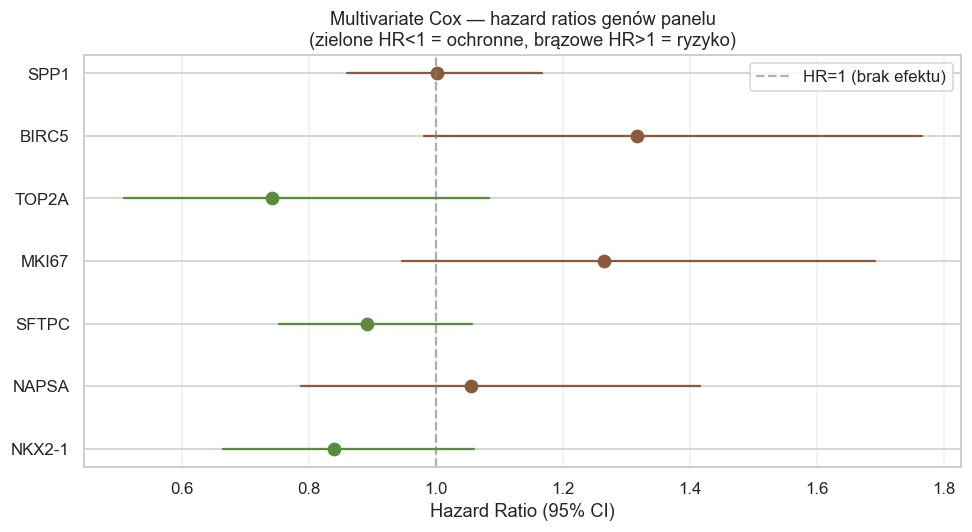


C-index modelu klinika+geny: 0.6858


In [18]:
# Porównanie C-index: model kliniczny (sekcja 6) vs klinika+geny
print("=== Porównanie modeli (C-index) ===")
print(f"  Model kliniczny (age+gender+stage):     {cph.concordance_index_:.4f}")
print(f"  Model klinika + panel genów:            {cph_genes.concordance_index_:.4f}")
delta = cph_genes.concordance_index_ - cph.concordance_index_
print(f"  Różnica (wkład genów):                  {delta:+.4f}")
print()
if delta > 0.01:
    print(f"  Panel genów POPRAWIA predykcję o {delta:.3f} C-index - kombinacja ekspresji")
    print(f"  dodaje wartość prognostyczną ponad sam model kliniczny.")
elif delta > 0:
    print(f"  Panel genów nieznacznie poprawia predykcję (+{delta:.3f}).")
else:
    print(f"  Panel genów nie poprawia C-index w tej kohorcie ({delta:+.3f}).")

# Forest plot tylko dla genów (kowarianty kliniczne już w sekcji 6)
fig, ax = plt.subplots(figsize=(9, 5))
summary = cph_genes.summary
gene_rows = summary.loc[[n for n in gene_feature_names if n in summary.index]]

hr = gene_rows["exp(coef)"]
ci_lower = gene_rows["exp(coef) lower 95%"]
ci_upper = gene_rows["exp(coef) upper 95%"]
y_pos = range(len(gene_rows))
labels = [n.replace("g_","").replace("_","-") for n in gene_rows.index]

colors_fp = [PALETTE["primary"] if h < 1 else PALETTE["secondary"] for h in hr]
for i, (h, lo, hi, col) in enumerate(zip(hr, ci_lower, ci_upper, colors_fp)):
    ax.plot([lo, hi], [i, i], color=col, linewidth=1.5)
    ax.plot(h, i, "o", color=col, markersize=8)

ax.axvline(1.0, color="grey", linestyle="--", alpha=0.6, label="HR=1 (brak efektu)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.set_xlabel("Hazard Ratio (95% CI)")
ax.set_title("Multivariate Cox — hazard ratios genów panelu\n(zielone HR<1 = ochronne, brązowe HR>1 = ryzyko)")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"\nC-index modelu klinika+geny: {cph_genes.concordance_index_:.4f}")


## 9. Wnioski

**Co zostało zademonstrowane:**

Pipeline LUAD-HUBA produkuje survival dataset, na którym standardowe metody analizy przeżywalności działają bez żadnych dodatkowych przekształceń:

1. **Kaplan-Meier overall** — mediana OS 4.11 lat, przeżycie 1/3/5-letnie (88%/63%/42%), realistyczne dla TCGA-LUAD
2. **KM per stage** — log-rank p=1.1×10⁻¹², idealny rozdział I>II>III>IV (sanity check kohorty)
3. **KM pojedynczy gen (NKX2-1)** — p=0.078, trend ale poniżej istotności (typowe dla pojedynczego markera)
4. **Sygnatura wielogenowa** — p=0.020, istotna tam gdzie pojedynczy gen nie był (kombinacja > pojedynczy marker)
5. **Cox kliniczny** — stage jedyny istotny predyktor (HR=1.64), C-index 0.66
6. **Multivariate Cox** (klinika + panel) — C-index 0.686 vs 0.661, panel dodaje wartość prognostyczną (+0.025)

**Cel pipeline'u osiągnięty:** dane TCGA-LUAD są przygotowane i gotowe do analizy przeżywalności.

**Kluczowy wynik metodologiczny:** pokazano że kombinacja genów (panel a priori z literatury, bez data snoopingu) niesie sygnał prognostyczny tam, gdzie pojedynczy gen go nie osiąga. To ilustruje że pipeline umożliwia analizę wielogenową.

**Ograniczenia:**
- Pojedyncze geny w multivariate nieistotne — siła w kombinacji, nie w pojedynczych predyktorach
- TOP2A HR odwrotny do biologii — artefakt kolinearności (skorelowany z MKI67/BIRC5)
- Geny driverowe LUAD (KRAS/EGFR/ALK) celowo pominięte — działają przez mutacje/fuzje niewidoczne w ekspresji RNA; wymagają danych mutacyjnych (future work)

**Możliwe rozszerzenia (poza zakresem baseline):**
- Feature selection na pełnej macierzy (LASSO, elastic net) z cross-validation
- Progression-free survival (PFI) przez TCGA-CDR
- Integracja danych mutacyjnych (MAF) — uchwycenie genów driverowych
- Modele ML/deep learning, multimodalność (histologia + RNA)

To są kierunki na przyszłość. Obecny pipeline dostarcza fundament: czyste, zintegrowane, gotowe do modelowania dane.
